# AI-Powered Resume Screening & Candidate Ranking System

## Objective

The goal of this project is to automate the resume screening process by analyzing candidate resumes, extracting skills and experience, comparing them against a job description, and ranking candidates based on relevance.

## Technologies Used

- Python
- Pandas
- NLTK
- Scikit-Learn
- TF-IDF
- Cosine Similarity
- PDFPlumber
- Matplotlib

## Ranking Formula

Final Score =
0.70 × Similarity Score +
0.20 × Skill Match Score +
0.10 × Experience Score

Resume PDF / CSV / Text
            ↓
     Text Extraction
            ↓
    NLP Preprocessing
            ↓
     Skill Extraction
            ↓
 Experience Extraction
            ↓
 TF-IDF Vectorization
            ↓
  Cosine Similarity
            ↓
    Candidate Ranking
            ↓
      Final Output

In [66]:
import pandas as pd
import numpy as np
import pdfplumber
import re
import nltk
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\aakan\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\aakan\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\aakan\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [67]:
## 1. Dataset Loading
df = pd.read_csv("data/Resume.csv")

print("Shape:", df.shape)

df.head()

Shape: (2484, 4)


,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [68]:
selected_categories = [
    "INFORMATION-TECHNOLOGY",
    "ENGINEERING",
    "CONSULTANT",
    "BANKING",
    "FINANCE"
]

df = df[df["Category"].isin(selected_categories)]

print(df.shape)

df["Category"].value_counts()

(586, 4)


Category
INFORMATION-TECHNOLOGY    120
FINANCE                   118
ENGINEERING               118
CONSULTANT                115
BANKING                   115
Name: count, dtype: int64

In [69]:
## 2. PDF Resume Extraction
def extract_pdf_text(pdf_path):

    text = ""

    with pdfplumber.open(pdf_path) as pdf:

        for page in pdf.pages:

            page_text = page.extract_text()

            if page_text:
                text += page_text + "\n"

    return text

In [70]:
my_resume_text = extract_pdf_text(
    "data/My_resume.pdf"
)

print(my_resume_text[:2000])

Aakancha Verma
Kolkata, West Bengal, India | Phone: +91-9875619163
Email: aakanchavermaofficial@gmail.com
LinkedIn: linkedin.com/in/aakancha-verma
Professional Summary
Final-yearComputerScienceandEngineeringundergraduatewithhands-onexperienceinArtificialIntelligence,Machine
Learning, DataAnalytics, andpredictivemodelingthroughacademicprojects, internships, andhackathonparticipation.
Skilled in Python, Java, data preprocessing, and analytical problem-solving, with practical exposure to developing
data-driven solutions and AI applications. Seeking opportunities to contribute to software development, AI/ML, and
data-driven engineering projects while continuously expanding technical expertise.
Education
Bachelor of Technology Institute of Engineering and Management, Newtown
Computer Science and Engineering 2023 – 2027
CGPA: 8.49
Senior Secondary Education Vision International School
PCM with Computer Science 2014 – 2022
Percentage in XII: 83.4
Percentage in X: 93.4
Key Coursework
Data Stru

In [71]:
## 3. NLP Preprocessing
stop_words = set(stopwords.words("english"))

lemmatizer = WordNetLemmatizer()

def preprocess_text(text):

    text = str(text).lower()

    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    tokens = text.split()

    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words
    ]

    return " ".join(tokens)

In [72]:
df["cleaned_resume"] = df["Resume_str"].apply(preprocess_text)

df[
    ["Category", "cleaned_resume"]
].head()

,Category,cleaned_resume
217,INFORMATION-TECHNOLOGY,information technology summary dedicated infor...
218,INFORMATION-TECHNOLOGY,information technology specialist g experience...
219,INFORMATION-TECHNOLOGY,information technology supervisor summary seek...
220,INFORMATION-TECHNOLOGY,information technology instructor summary seve...
221,INFORMATION-TECHNOLOGY,information technology manager analyst profess...


In [73]:
my_resume_clean = preprocess_text(
    my_resume_text
)

print(my_resume_clean[:1000])

aakancha verma kolkata west bengal india phone email aakanchavermaofficial gmail com linkedin linkedin com aakancha verma professional summary final yearcomputerscienceandengineeringundergraduatewithhands onexperienceinartificialintelligence machine learning dataanalytics andpredictivemodelingthroughacademicprojects internship andhackathonparticipation skilled python java data preprocessing analytical problem solving practical exposure developing data driven solution ai application seeking opportunity contribute software development ai ml data driven engineering project continuously expanding technical expertise education bachelor technology institute engineering management newtown computer science engineering cgpa senior secondary education vision international school pcm computer science percentage xii percentage x key coursework data structure algorithm object oriented programming database management system operating system artificial intelligence machine learning fundamental techni

In [74]:
job_description = """
AI/ML Engineer

Required Skills:
Python
Machine Learning
Deep Learning
TensorFlow
SQL
Data Visualization

Preferred Skills:
NLP
Streamlit
Git

Experience:
0-2 years
"""

job_description

'\nAI/ML Engineer\n\nRequired Skills:\nPython\nMachine Learning\nDeep Learning\nTensorFlow\nSQL\nData Visualization\n\nPreferred Skills:\nNLP\nStreamlit\nGit\n\nExperience:\n0-2 years\n'

In [75]:
cleaned_jd = preprocess_text(job_description)

print(cleaned_jd)

ai ml engineer required skill python machine learning deep learning tensorflow sql data visualization preferred skill nlp streamlit git experience year


In [76]:
## 4. Skill Extraction
skills_list = [
    "python",
    "java",
    "sql",
    "machine learning",
    "deep learning",
    "tensorflow",
    "pytorch",
    "nlp",
    "streamlit",
    "flask",
    "git",
    "tableau",
    "power bi",
    "excel",
    "aws",
    "docker",
    "kubernetes",
    "data analysis",
    "data visualization",
    "statistics",
    "c++",
    "html",
    "css",
    "javascript",
    "react"
]

In [77]:
def extract_skills(text):

    text = str(text).lower()

    found_skills = []

    for skill in skills_list:

        if skill.lower() in text:
            found_skills.append(skill)

    return list(set(found_skills))

In [78]:
df["skills"] = df["Resume_str"].apply(
    extract_skills
)

df[["Category","skills"]].head()

,Category,skills
217,INFORMATION-TECHNOLOGY,"[html, excel]"
218,INFORMATION-TECHNOLOGY,[]
219,INFORMATION-TECHNOLOGY,[excel]
220,INFORMATION-TECHNOLOGY,"[html, data analysis, excel]"
221,INFORMATION-TECHNOLOGY,[data analysis]


In [79]:
jd_skills = extract_skills(job_description)

print(jd_skills)

['sql', 'nlp', 'streamlit', 'git', 'tensorflow', 'deep learning', 'data visualization', 'machine learning', 'python']


In [80]:
def calculate_skill_match(
    candidate_skills,
    jd_skills
):

    if len(jd_skills) == 0:
        return 0

    matched = set(candidate_skills).intersection(
        set(jd_skills)
    )

    return (
        len(matched) /
        len(jd_skills)
    ) * 100

In [81]:
df["skill_match_score"] = df["skills"].apply(
    lambda x:
    calculate_skill_match(
        x,
        jd_skills
    )
)

In [82]:
df[
    ["skills","skill_match_score"]
].head()

,skills,skill_match_score
217,"[html, excel]",0.0
218,[],0.0
219,[excel],0.0
220,"[html, data analysis, excel]",0.0
221,[data analysis],0.0


In [83]:
## 5. Experience Extraction
def extract_experience(text):

    text = str(text).lower()

    patterns = [
        r'(\d+)\+?\s+years',
        r'(\d+)\+?\s+yrs',
        r'(\d+)\+?\s+year'
    ]

    for pattern in patterns:

        match = re.search(
            pattern,
            text
        )

        if match:
            return int(match.group(1))

    return 0

In [84]:
df["experience_years"] = (
    df["Resume_str"]
    .apply(extract_experience)
)

df[
    ["experience_years"]
].describe()

,experience_years
count,586.000000
mean,14.018771
std,125.958729
min,0.000000
25%,0.000000
50%,0.000000
75%,9.000000
max,2015.000000


In [85]:
def experience_score(
    candidate_exp,
    required_exp=2
):

    if candidate_exp >= required_exp:
        return 100

    return (
        candidate_exp /
        required_exp
    ) * 100

In [86]:
df["experience_score"] = (
    df["experience_years"]
    .apply(experience_score)
)

In [87]:
## 6. Feature Engineering and Similarity Scoring
all_resumes = df["cleaned_resume"].tolist()

corpus = all_resumes + [cleaned_jd]

vectorizer = TfidfVectorizer()

tfidf_matrix = vectorizer.fit_transform(
    corpus
)

jd_vector = tfidf_matrix[-1]
resume_vectors = tfidf_matrix[:-1]
similarity_scores = cosine_similarity(
    resume_vectors,
    jd_vector
)
df["similarity_score"] = (
    similarity_scores.flatten() * 100
)
df[
    ["Category","similarity_score"]
].sort_values(
    "similarity_score",
    ascending=False
).head(10)

,Category,similarity_score
1218,CONSULTANT,15.864207
1762,ENGINEERING,13.663088
2153,BANKING,11.884483
1737,ENGINEERING,9.139098
1142,CONSULTANT,7.807912
1750,ENGINEERING,7.084778
267,INFORMATION-TECHNOLOGY,7.078175
243,INFORMATION-TECHNOLOGY,6.090600
1707,ENGINEERING,5.748709
220,INFORMATION-TECHNOLOGY,5.664852


In [88]:
df["similarity_score"] = (
    df["similarity_score"]
    /
    df["similarity_score"].max()
) * 100
df["final_score"] = (
    0.70 * df["similarity_score"]
    +
    0.20 * df["skill_match_score"]
    +
    0.10 * df["experience_score"]
)
ranked_df = df.sort_values(
    "final_score",
    ascending=False
)

ranked_df[
[
    "Category",
    "similarity_score",
    "skill_match_score",
    "experience_score",
    "final_score"
]
].head(20)

,Category,similarity_score,skill_match_score,experience_score,final_score
1218,CONSULTANT,100.000000,44.444444,100.0,88.888889
1762,ENGINEERING,86.125246,44.444444,100.0,79.176561
2153,BANKING,74.913812,33.333333,0.0,59.106335
1737,ENGINEERING,57.608288,0.000000,100.0,50.325801
1750,ENGINEERING,44.658881,33.333333,100.0,47.927884
267,INFORMATION-TECHNOLOGY,44.617263,33.333333,100.0,47.898751
2199,BANKING,27.632955,44.444444,100.0,38.231957
1135,CONSULTANT,33.082057,22.222222,100.0,37.601884
297,INFORMATION-TECHNOLOGY,32.754749,22.222222,100.0,37.372768
1142,CONSULTANT,49.217161,11.111111,0.0,36.674235


In [89]:
## 7. Candidate Ranking Logic
ranked_df = ranked_df.reset_index(
    drop=True
)

ranked_df["Rank"] = (
    ranked_df.index + 1
)
ranked_df[
[
    "Rank",
    "Category",
    "similarity_score",
    "skill_match_score",
    "experience_score",
    "final_score"
]
].head(20)

,Rank,Category,similarity_score,skill_match_score,experience_score,final_score
0,1,CONSULTANT,100.000000,44.444444,100.0,88.888889
1,2,ENGINEERING,86.125246,44.444444,100.0,79.176561
2,3,BANKING,74.913812,33.333333,0.0,59.106335
3,4,ENGINEERING,57.608288,0.000000,100.0,50.325801
4,5,ENGINEERING,44.658881,33.333333,100.0,47.927884
5,6,INFORMATION-TECHNOLOGY,44.617263,33.333333,100.0,47.898751
6,7,BANKING,27.632955,44.444444,100.0,38.231957
7,8,CONSULTANT,33.082057,22.222222,100.0,37.601884
8,9,INFORMATION-TECHNOLOGY,32.754749,22.222222,100.0,37.372768
9,10,CONSULTANT,49.217161,11.111111,0.0,36.674235


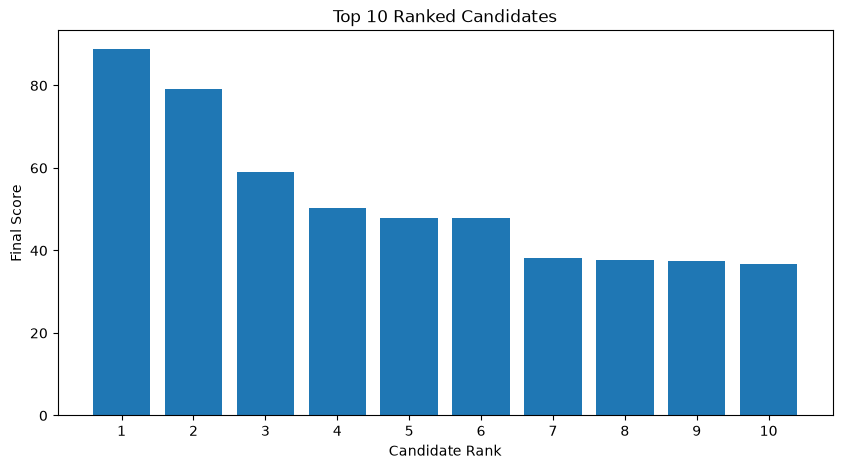

In [90]:
## 8. Data Visualization
top10 = ranked_df.head(10)

plt.figure(figsize=(10,5))

plt.bar(
    range(len(top10)),
    top10["final_score"]
)

plt.xticks(
    range(len(top10)),
    top10["Rank"]
)

plt.xlabel("Candidate Rank")
plt.ylabel("Final Score")

plt.title(
    "Top 10 Ranked Candidates"
)

plt.show()

In [91]:
## 9. Skill Gap Analysis
def skill_gap_analysis(
    candidate_skills,
    jd_skills
):

    matched = list(
        set(candidate_skills)
        &
        set(jd_skills)
    )

    missing = list(
        set(jd_skills)
        -
        set(candidate_skills)
    )

    return matched, missing
ranked_df["matched_skills"] = (
    ranked_df["skills"]
    .apply(
        lambda x:
        skill_gap_analysis(
            x,
            jd_skills
        )[0]
    )
)

ranked_df["missing_skills"] = (
    ranked_df["skills"]
    .apply(
        lambda x:
        skill_gap_analysis(
            x,
            jd_skills
        )[1]
    )
)
ranked_df[
[
    "Rank",
    "matched_skills",
    "missing_skills"
]
].head()

,Rank,matched_skills,missing_skills
0,1,"[sql, data visualization, machine learning, py...","[nlp, streamlit, git, tensorflow, deep learning]"
1,2,"[sql, data visualization, machine learning, py...","[nlp, streamlit, git, tensorflow, deep learning]"
2,3,"[sql, machine learning, python]","[nlp, streamlit, git, tensorflow, deep learnin..."
3,4,[],"[sql, nlp, streamlit, git, tensorflow, deep le..."
4,5,"[sql, git, python]","[nlp, streamlit, tensorflow, deep learning, da..."


In [92]:
my_skills = extract_skills(
    my_resume_text
)

my_exp = extract_experience(
    my_resume_text
)

my_cleaned = preprocess_text(
    my_resume_text
)



In [93]:
my_resume_cleaned = preprocess_text(
    my_resume_text
)

my_resume_skills = extract_skills(
    my_resume_text
)

my_resume_skill_match = (
    calculate_skill_match(
        my_resume_skills,
        jd_skills
    )
)

my_resume_exp = extract_experience(
    my_resume_text
)

my_resume_exp_score = (
    experience_score(
        my_resume_exp
    )
)

In [94]:
temp_corpus = [
    my_resume_cleaned,
    cleaned_jd
]

temp_tfidf = (
    vectorizer.fit_transform(
        temp_corpus
    )
)

my_similarity = (
    cosine_similarity(
        temp_tfidf[0:1],
        temp_tfidf[1:2]
    )[0][0]
) * 100

In [95]:
## 10. Result Export
my_final_score = (
    0.70 * my_similarity
    +
    0.20 * my_resume_skill_match
    +
    0.10 * my_resume_exp_score
)

print("Similarity:", my_similarity)
print("Skill Match:", my_resume_skill_match)
print("Experience:", my_resume_exp_score)
print("Final Score:", my_final_score)

Similarity: 26.97267516057445
Skill Match: 22.22222222222222
Experience: 0.0
Final Score: 23.325317056846558


In [96]:
my_rank = (
    (ranked_df["final_score"] >
     my_final_score)
    .sum()
    + 1
)

print(
    f"My Resume Rank: {my_rank}"
)

My Resume Rank: 60


In [97]:
#Text Input Demonstration
manual_resume = """
Python Developer

Skills:
Python
SQL
Machine Learning
TensorFlow
Git
Streamlit

Experience:
2 years
"""

In [98]:
manual_clean = preprocess_text(
    manual_resume
)

manual_skills = extract_skills(
    manual_resume
)

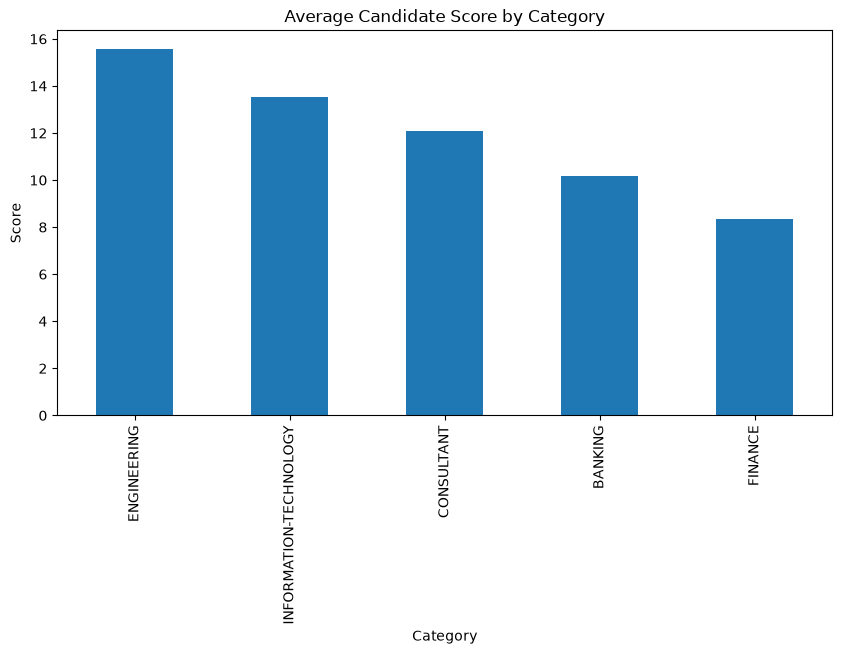

In [99]:
category_scores = (
    ranked_df
    .groupby("Category")
    ["final_score"]
    .mean()
    .sort_values(
        ascending=False
    )
)

plt.figure(
    figsize=(10,5)
)

category_scores.plot(
    kind="bar"
)

plt.title(
    "Average Candidate Score by Category"
)

plt.ylabel("Score")

plt.show()

In [100]:
top_candidate = ranked_df.iloc[0]

print("Top Candidate Category:",
      top_candidate["Category"])

print("Final Score:",
      round(top_candidate["final_score"],2))

Top Candidate Category: CONSULTANT
Final Score: 88.89


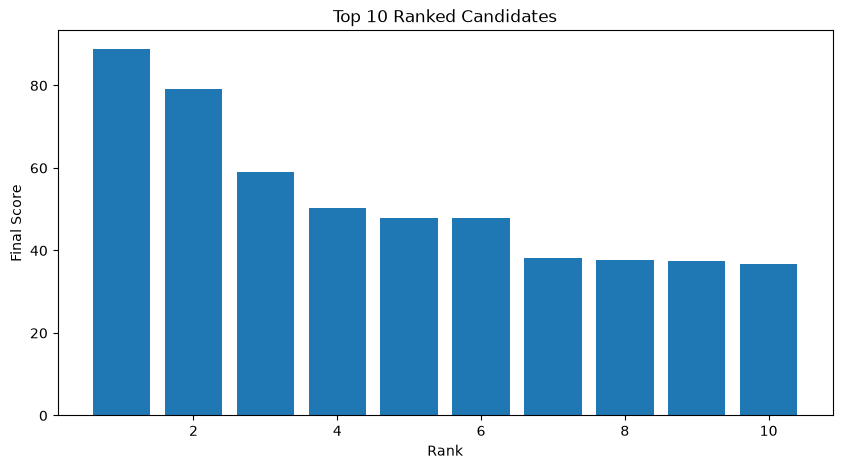

In [101]:
top10 = ranked_df.head(10)

plt.figure(
    figsize=(10,5)
)

plt.bar(
    top10["Rank"],
    top10["final_score"]
)

plt.title(
    "Top 10 Ranked Candidates"
)

plt.xlabel(
    "Rank"
)

plt.ylabel(
    "Final Score"
)

plt.show()

In [102]:
ranked_df.to_csv(
    "outputs/ranking_results.csv",
    index=False
)
ranked_df.to_excel(
    "outputs/ranking_results.xlsx",
    index=False
)

C:\Users\aakan\AppData\Local\Temp\ipykernel_36656\696262832.py:5: UserWarning: Cell contents too long (35557), truncated to 32767 characters
  ranked_df.to_excel(
C:\Users\aakan\AppData\Local\Temp\ipykernel_36656\696262832.py:5: UserWarning: Cell contents too long (52302), truncated to 32767 characters
  ranked_df.to_excel(
C:\Users\aakan\AppData\Local\Temp\ipykernel_36656\696262832.py:5: UserWarning: Cell contents too long (34534), truncated to 32767 characters
  ranked_df.to_excel(
C:\Users\aakan\AppData\Local\Temp\ipykernel_36656\696262832.py:5: UserWarning: Cell contents too long (44135), truncated to 32767 characters
  ranked_df.to_excel(
C:\Users\aakan\AppData\Local\Temp\ipykernel_36656\696262832.py:5: UserWarning: Cell contents too long (48868), truncated to 32767 characters
  ranked_df.to_excel(


## Limitations

- Skill extraction relies on keyword matching.
- Experience extraction uses regex patterns.
- Semantic understanding is limited compared to transformer models.
- Ranking quality depends on resume quality.

## Future Enhancements

- BERT/Sentence Transformers
- Named Entity Recognition
- LLM-based Resume Summarization
- Bias Detection
- Recruiter Feedback Loop